#### Exact Matching  Evaluierung

In [136]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from evaluate_functions_p1 import *
from plot_functions_p1 import *

### Wähle den evaluations Ordner

In [137]:
versuch_ordner = "eval_p1_finetuned_8b_prompt2/" #"eval_p1_finetuned_8b_prompt2/" "eval_n_shot/eval_5_shot_best/"   #"eval_p1_finetuned_8b_prompt2/" #"eval_n_shot/eval_5_shot/"
versuch_name = "tuned"



label_folder = '../input/lct_p1'
raw_lct_text_folder = '../input/lct_txt'
model_output_folder = versuch_ordner + 'model_output'

models = [folder for folder in os.listdir(model_output_folder) if os.path.isdir(os.path.join(model_output_folder, folder))]
# ### N-shot Modelle Reihenfolge
#models = ['Llama-3-8B-Instruct_5_shot',  'Llama-3-70B-Instruct_5_shot', 'OpenBioLLM-Llama3-8B_5_shot', 'OpenBioLLM-Llama3-70B_5_shot', 'Gemma-27b_5_shot', 'Llama-3-8B-Instruct-Gradient_15_shot', 'Llama-3-70B-Instruct-Gradient_15_shot', 'Qwen2-72B_15_shot' ] # 'Llama-3-70B-Hermes2_5_shot'

models

['70B_EP10_r128',
 '70B_EP40_r128',
 '8B_EP10_r128',
 '8B_EP10_r128_a350',
 '8B_EP10_r2048',
 '8B_EP10_r512',
 '8B_EP20_r2048',
 '8B_EP30_r128',
 '8B_EP40_r128',
 '8B_EP80_r128']

In [138]:
all_metrics = {}
for model in models:
    model_folder = os.path.join(model_output_folder, model, 'output')
    metrics = evaluate_models(label_folder, model_folder, model, raw_lct_text_folder)
    all_metrics[model] = metrics

    # Berechne die durchschnittliche Performance über alle Operatoren
    # avg_metrics = {'precision': 0, 'recall': 0, 'f1': 0, 'accuracy': 0}
    # for metric in avg_metrics.keys():
    #     print(metric)
    #     avg_metrics[metric] = sum(metrics[op][metric] for op in metrics) / len(metrics)
    # 
    # # Attach the average scores to the model's metrics
    # metrics['average'] = avg_metrics
    # all_metrics[model] = metrics
    

### Missing Words PCT

In [139]:
def plot_avg_pct(all_metrics):
    model_names = []
    avg_missing_pcts = []
    avg_zuviel_pcts = []

    for model, metrics in all_metrics.items():
        model_names.append(model.replace('-Instruct', ''))  # Entferne "-Instruct" aus den Modellnamen
        avg_missing_pcts.append(metrics['average_missing_percentage'])
        avg_zuviel_pcts.append(metrics['average_zuviel_percentage'])
        model_names = [name.replace('-Instruct', '') for name in model_names]
    model_names = [name.replace('_', '-') for name in model_names]
    model_names = [name.replace('Gradient', 'Grad') for name in model_names]
    model_names = [name.replace('Llama-3', 'Llama3') for name in model_names]
    model_names = [name.replace('prompt-', 'p') for name in model_names]
    #model_names = [name.replace('-0-shot', '') for name in model_names]
    x = range(len(model_names))

    plt.figure(figsize=(14, 8))

    bar_width = 0.4
    plt.bar(x, avg_missing_pcts, color='skyblue', width=bar_width, label='Mittlere Anzahl fehlender Wörter')
    plt.bar([p + bar_width for p in x], avg_zuviel_pcts, color='lightcoral', width=bar_width, label='Mittlere Anzahl zugefügter Wörter')

    plt.xlabel('Modelle', fontsize=14)
    plt.ylabel('Prozentsatz (%)', fontsize=14)
    plt.title(f'Durchschnittlicher Prozentsatz fehlender und zugefügter Wörter der {versuch_name}', fontsize=18, pad=20)
    plt.xticks([p + bar_width / 2 for p in x], model_names, rotation=45, ha='right', fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0, max(max(avg_missing_pcts), max(avg_zuviel_pcts)) + 5)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()

    for i, (v1, v2) in enumerate(zip(avg_missing_pcts, avg_zuviel_pcts)):
        plt.text(i, v1 + 0.5, f'{v1:.1f}%', ha='center', fontsize=12)
        plt.text(i + bar_width, v2 + 0.5, f'{v2:.1f}%', ha='center', fontsize=12)

    plt.tight_layout()
    plt.savefig(f'pics/missing_pct_{versuch_name}.png')
    plt.show()


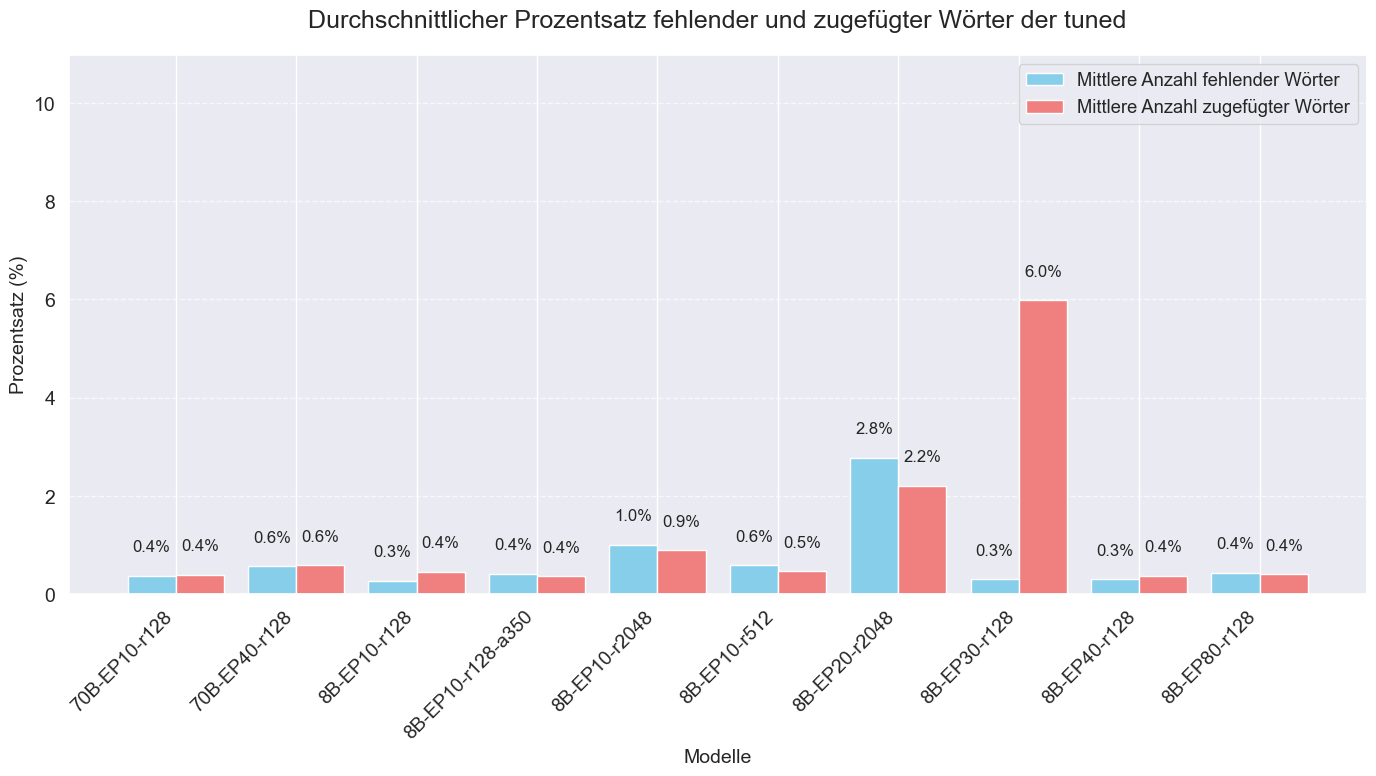

In [140]:
plot_avg_pct(all_metrics)

In [141]:
def plot_avg_metrics(all_metrics):
    sota_metrics = {
        'SciBERT (SOTA)': {
            'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
        },
        'R-BERT + SciBERT': {
            'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
        }
    }
    metrics_to_plot = ['precision', 'recall', 'f1']
    model_names = ['SciBERT (SOTA)'] + list(all_metrics.keys())
    model_names = [name.replace('-Instruct', '') for name in model_names]
    model_names = [name.replace('_', '-') for name in model_names]
    model_names = [name.replace('Gradient', 'Grad') for name in model_names]
    model_names = [name.replace('Llama-3', 'Llama3') for name in model_names]

    avg_precisions = [sota_metrics['SciBERT (SOTA)']['average']['precision']]
    avg_recalls = [sota_metrics['SciBERT (SOTA)']['average']['recall']]
    avg_f1_scores = [sota_metrics['SciBERT (SOTA)']['average']['f1']]

    for model, metrics in all_metrics.items():
        avg_precisions.append(metrics['average']['precision'])
        avg_recalls.append(metrics['average']['recall'])
        avg_f1_scores.append(metrics['average']['f1'])

    x = np.arange(len(model_names) * 4)
    bar_width = 1.8  # Breitere Balken
    opacity = 0.8
    gap = 0.97 # Abstand zwischen den Balken
    model_gap = 1.0  # Abstand zwischen den Modellen

    plt.figure(figsize=(18, 12))  # Größere Figur
    sns.set(style='darkgrid', font_scale=1.2)
    sns.set_palette('deep')
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Bessere Farben
    for i in range(len(model_names)):
        plt.bar(x[i * 4], avg_precisions[i], bar_width - gap, alpha=opacity, label='Precision' if i == 0 else '', color=colors[0])
        plt.bar(x[i * 4 + 1], avg_recalls[i], bar_width - gap, alpha=opacity, label='Recall' if i == 0 else '', color=colors[1])
        plt.bar(x[i * 4 + 2], avg_f1_scores[i], bar_width - gap, alpha=opacity, label='F1 Score' if i == 0 else '', color=colors[2])

    plt.xlabel('Modelle', fontsize=16)
    plt.ylabel('Score (%)', fontsize=16)
    plt.title(f'{versuch_name}: Durchschnittliche Leistung für AND, OR, NOT Operatoren ', fontsize=18, pad=25)

    # Finde den Index des Modells mit dem höchsten F1-Score (ausgenommen SciBERT (SOTA) und Naive greedy match)
    max_f1 = max(avg_f1_scores[1:])
    max_f1 = round(max_f1,1)# SciBERT (SOTA) ausgeschlossen
    max_f1_indices = [i + 1 for i, f1 in enumerate(avg_f1_scores[1:]) if round(f1,1) == max_f1]
    tick_labels = [
        f'${{\\bf {name} }}$' if i in max_f1_indices else name
        for i, name in enumerate(model_names)
]

    plt.xticks(x[1::4], tick_labels, rotation=40, ha='right', fontsize=16)
    plt.ylim(0, 100)
    plt.yticks(fontsize=14)  # Größere Zahlen an der y-Achse
    plt.legend(title='Metriken', fontsize=12)
    plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)

    y_offset = 2  # Abstand zwischen Balken und Prozentzahlen
    for i in range(len(model_names)):
        plt.text(x[i * 4], avg_precisions[i] + y_offset, f'{avg_precisions[i]:.1f}%', ha='center', fontsize=10)
        plt.text(x[i * 4 + 1], avg_recalls[i] + y_offset, f'{avg_recalls[i]:.1f}%', ha='center', fontsize=10)
        plt.text(x[i * 4 + 2], avg_f1_scores[i] + y_offset, f'{avg_f1_scores[i]:.1f}%', ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'pics/all_operators_{versuch_name}.png')
    plt.show()

In [142]:
all_metrics

{'70B_EP10_r128': {'AND': {'precision': 62.2093023255814,
   'recall': 66.0493827160494,
   'f1': 64.07185628742515,
   'accuracy': 66.0493827160494,
   'total_label': 162,
   'total_model': 175,
   'correct_count': 107,
   'low_tp_ncts': []},
  'OR': {'precision': 84.90127758420442,
   'recall': 91.375,
   'f1': 88.01926550270922,
   'accuracy': 91.375,
   'total_label': 800,
   'total_model': 866,
   'correct_count': 731,
   'low_tp_ncts': []},
  'NOT': {'precision': 75.11961722488039,
   'recall': 84.86486486486487,
   'f1': 79.69543147208121,
   'accuracy': 84.86486486486487,
   'total_label': 185,
   'total_model': 211,
   'correct_count': 157,
   'low_tp_ncts': []},
  'average_missing_percentage': 0.366540331306062,
  'average_zuviel_percentage': 0.38066790545479834,
  'total_missing_words': Counter({',': 4,
           '(no': 3,
           'physical/sports': 2,
           'Age:': 2,
           'Years': 2,
           'Systolic/diastolic': 2,
           'paresis/paralysis)': 1,
   

In [143]:
def calculate_mean_excel(data, model_names, file_path='excel/n_shot_mean_results.xlsx'):
    n_shot_models = [model for model in data.keys() if model.startswith(model_names)]
    precisions = []
    recalls = []
    f1_scores = []
    missing_percentages = []
    excess_percentages = []

    for model in n_shot_models:
        print(model)
        avg = data[model]['average']
        precisions.append(avg['precision'])
        recalls.append(avg['recall'])
        f1_scores.append(avg['f1'])
        missing_percentages.append(data[model]['average_missing_percentage'])
        excess_percentages.append(data[model]['average_zuviel_percentage'])

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)
    avg_f1 = np.mean(f1_scores)
    avg_missing_percentage = np.mean(missing_percentages)
    avg_excess_percentage = np.mean(excess_percentages)
    print(avg_missing_percentage)
    std_precision = np.std(precisions)
    std_recall = np.std(recalls)
    std_f1 = np.std(f1_scores)
    std_missing_percentage = np.std(missing_percentages)
    std_excess_percentage = np.std(excess_percentages)

    result = {
        'average_precision': avg_precision,
        'average_recall': avg_recall,
        'average_f1': avg_f1,
        'std_precision': std_precision,
        'std_recall': std_recall,
        'std_f1': std_f1,
        'average_missing_percentage': avg_missing_percentage,
        'average_excess_percentage': avg_excess_percentage,
        'std_missing_percentage': std_missing_percentage,
        'std_excess_percentage': std_excess_percentage
    }

    df = pd.DataFrame(result, index=[model_names])
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    if os.path.exists(file_path):
        existing_df = pd.read_excel(file_path, index_col=0)
        existing_df.update(df)
        df = pd.concat([existing_df, df[~df.index.isin(existing_df.index)]])

    df.to_excel(file_path)
    print(f"Results saved/updated in {file_path}")

    return result

In [144]:
#calculate_mean_excel(all_metrics, model_names="3_shot")

### Durchschnittliche Performance über alle Operatoren [AND, OR, NOT] 

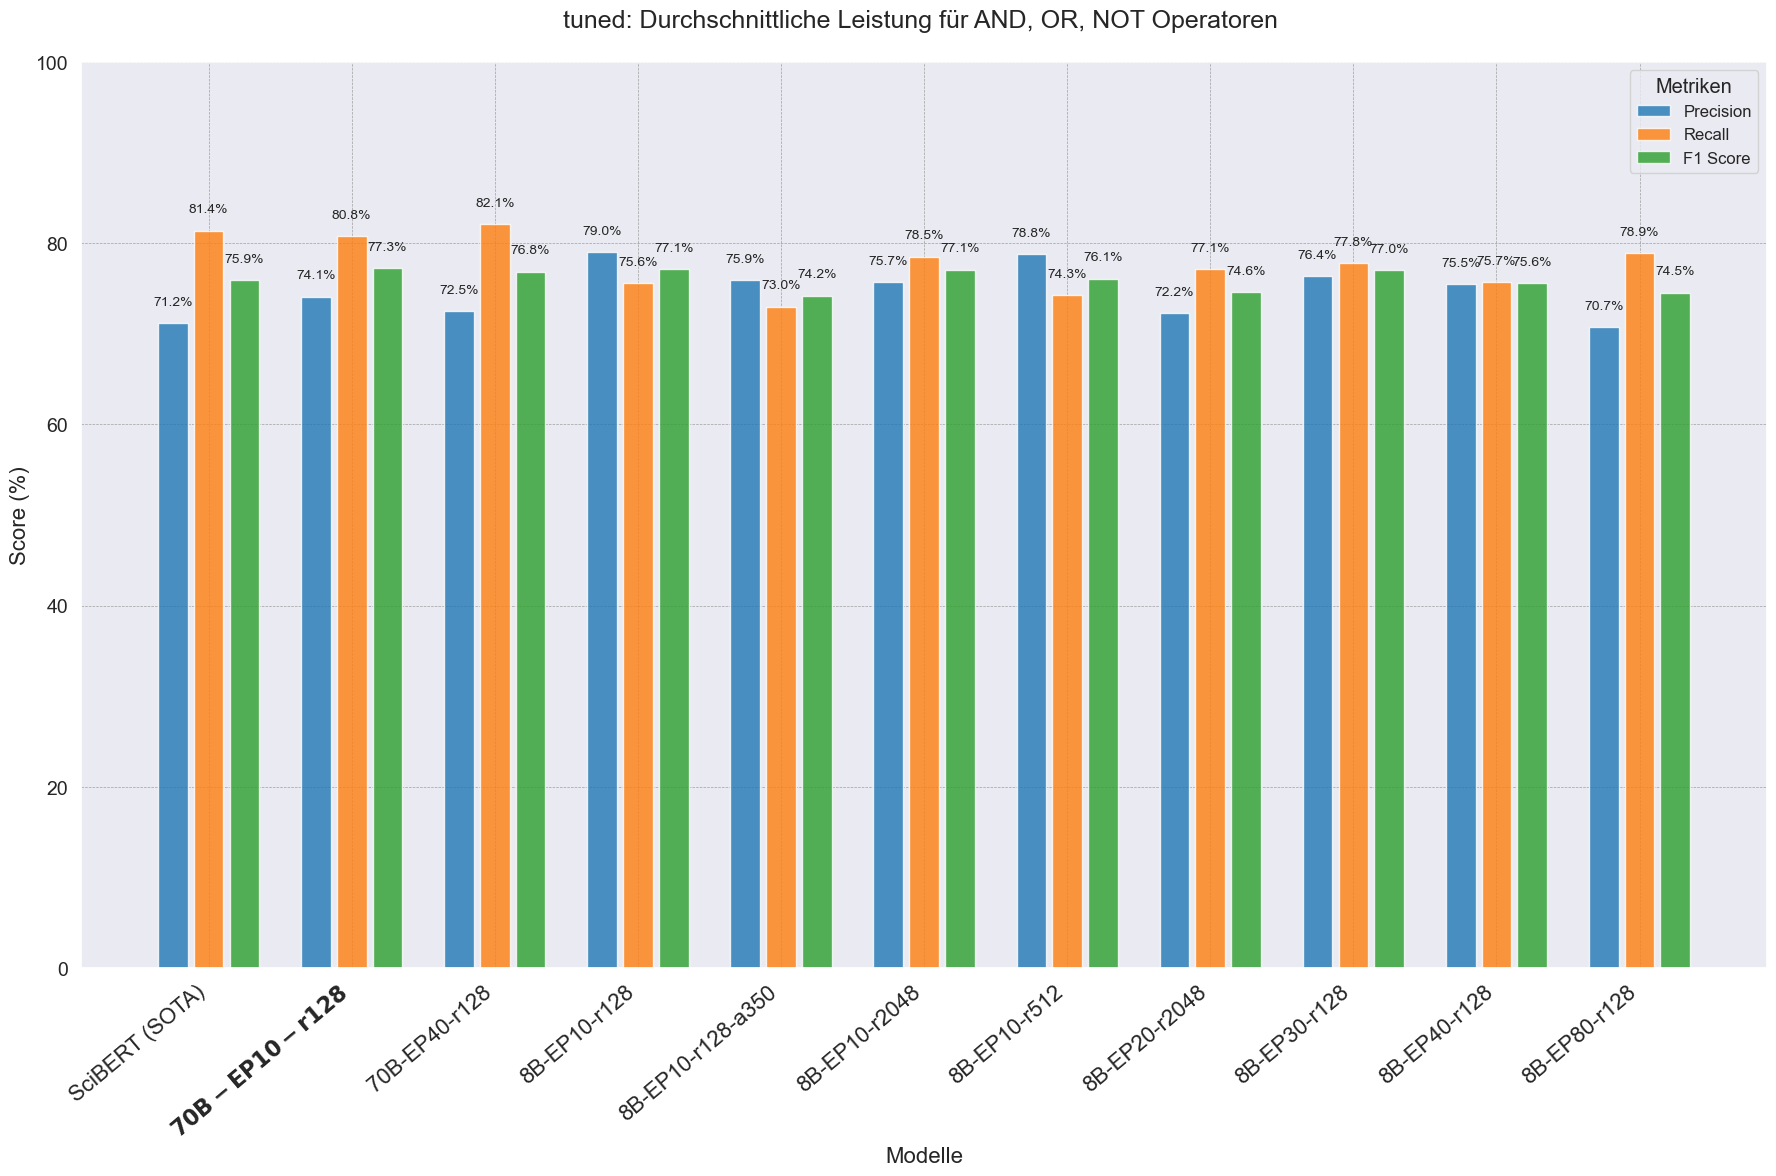

In [145]:
plot_avg_metrics(all_metrics)

In [146]:
def generate_latex_table_avg(all_metrics, versuch_name):
    metrics_to_plot = ['precision', 'recall', 'f1']

    # SOTA metrics
    sota_metrics = {
        'SciBERT (SOTA)': {
            'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
        },
        'R-BERT + SciBERT': {
            'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
        }
    }

    # Find the maximum values per column
    max_values = {metric: float('-inf') for metric in metrics_to_plot}

    # Update max_values with SOTA and all other models
    for model_metrics in [*sota_metrics.values(), *all_metrics.values()]:
        for metric in metrics_to_plot:
            value = model_metrics['average'][metric]
            if value > max_values[metric]:
                max_values[metric] = value

    latex_table = "\\begin{table}[h]\n"
    latex_table += "\\centering\n"
    latex_table += "\\begin{tabular}{lccc}\n"
    latex_table += "\\toprule\n"
    latex_table += "Model & Precision & Recall & F1 \\\\\n"
    latex_table += "\\midrule\n"

    # Add rows for SOTA models
    for name, values in sota_metrics.items():
        row = name.replace("_", "-")
        for metric in metrics_to_plot:
            value = values['average'][metric]
            formatted_value = "{:.1f}".format(value)
            if value == max_values[metric]:
                formatted_value = f"\\textbf{{{formatted_value}}}"
            row += f" & {formatted_value}"
        row += " \\\\\n"
        latex_table += row

    # Add rows for other models
    for model, model_metrics in all_metrics.items():
        row = model.replace("_", "-")
        for metric in metrics_to_plot:
            value = model_metrics['average'][metric]
            formatted_value = "{:.1f}".format(value)
            if value == max_values[metric]:
                formatted_value = f"\\textbf{{{formatted_value}}}"
            row += f" & {formatted_value}"
        row += " \\\\\n"
        latex_table += row

    latex_table += "\\bottomrule\n"
    latex_table += "\\end{tabular}\n"
    latex_table += f"\\caption{{Average Model Performance Metrics for {versuch_name}}}\n"
    latex_table += "\\label{tab:avg_model_metrics}\n"
    latex_table += "\\end{table}\n"

    os.makedirs("latex", exist_ok=True)
    with open(f"latex/{versuch_name}.tex", "w") as file:
        file.write(latex_table)
    return latex_table

In [147]:
generate_latex_table_avg(all_metrics, versuch_name)

'\\begin{table}[h]\n\\centering\n\\begin{tabular}{lccc}\n\\toprule\nModel & Precision & Recall & F1 \\\\\n\\midrule\nSciBERT (SOTA) & 71.2 & 81.4 & 75.9 \\\\\nR-BERT + SciBERT & 72.2 & 78.2 & 75.0 \\\\\n70B-EP10-r128 & 74.1 & 80.8 & \\textbf{77.3} \\\\\n70B-EP40-r128 & 72.5 & \\textbf{82.1} & 76.8 \\\\\n8B-EP10-r128 & \\textbf{79.0} & 75.6 & 77.1 \\\\\n8B-EP10-r128-a350 & 75.9 & 73.0 & 74.2 \\\\\n8B-EP10-r2048 & 75.7 & 78.5 & 77.1 \\\\\n8B-EP10-r512 & 78.8 & 74.3 & 76.1 \\\\\n8B-EP20-r2048 & 72.2 & 77.1 & 74.6 \\\\\n8B-EP30-r128 & 76.4 & 77.8 & 77.0 \\\\\n8B-EP40-r128 & 75.5 & 75.7 & 75.6 \\\\\n8B-EP80-r128 & 70.7 & 78.9 & 74.5 \\\\\n\\bottomrule\n\\end{tabular}\n\\caption{Average Model Performance Metrics for tuned}\n\\label{tab:avg_model_metrics}\n\\end{table}\n'

### Perfomance der einzelnen Operatoren

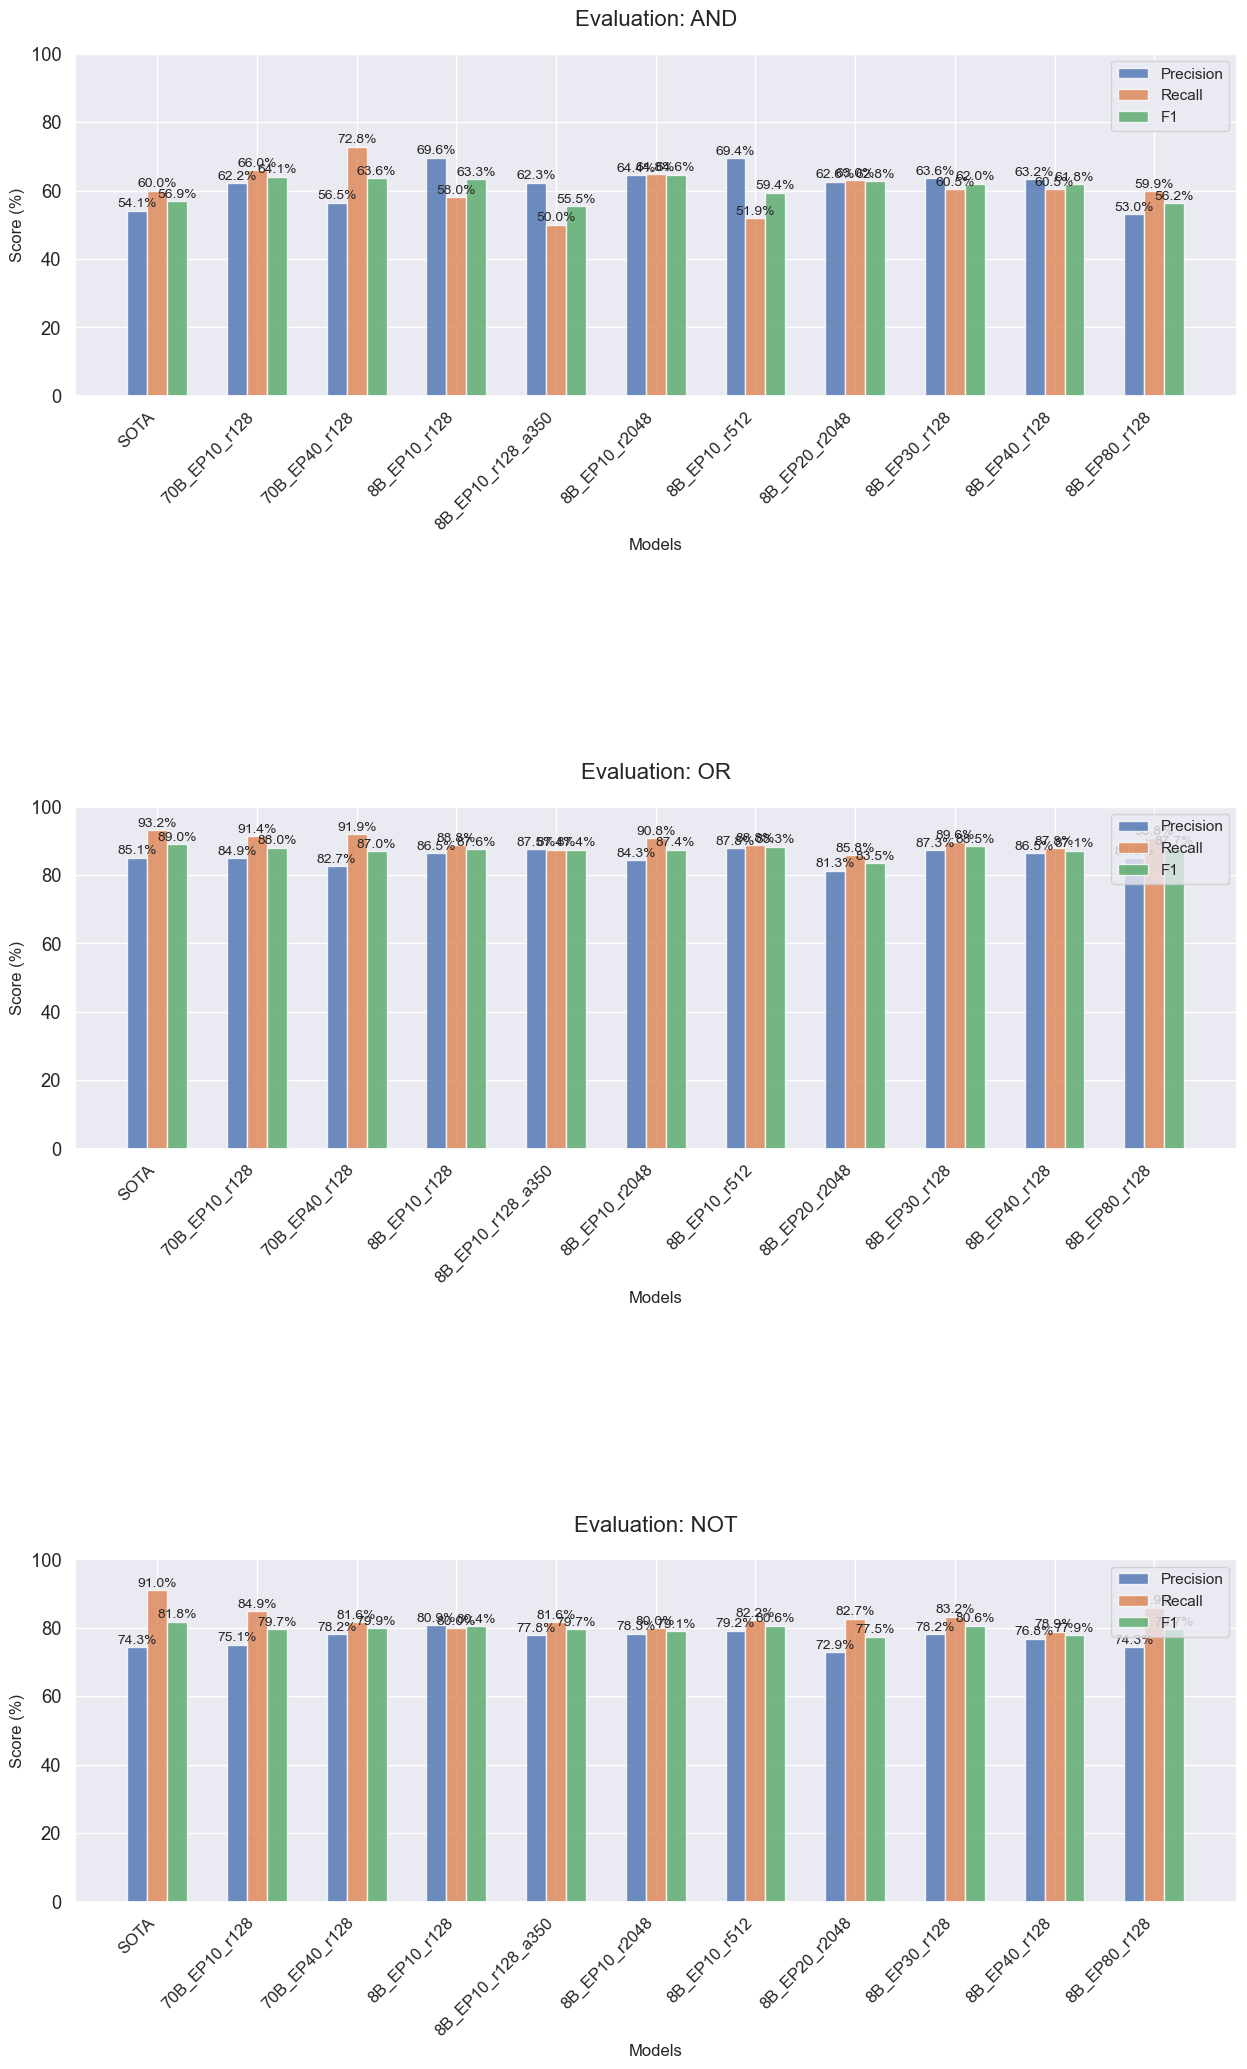

In [148]:
plot_metrics(all_metrics)

### Plot Anzahl Operators

In [12]:
def plot_count_comparison(all_metrics):
    operators = ['AND', 'OR', 'NOT']
    count_metrics = ['total_label', 'total_model']
    fig, ax = plt.subplots(figsize=(16, 8))
    x = np.arange(len(operators))

    label_counts = [all_metrics[next(iter(all_metrics))][op]['total_label'] for op in operators]
    bar_width = 0.16
    opacity = 0.8

    colors = sns.color_palette("husl", len(all_metrics) + 1)

    ax.bar(x, label_counts, bar_width, alpha=opacity, color=colors[0], label='Label Count')
    for i, model in enumerate(all_metrics.keys()):
        count_values = [all_metrics[model][op]['total_model'] for op in operators]
        model_name = model.replace('Instruct', '').replace('_', ' ')
        ax.bar(x + (i + 1) * bar_width, count_values, bar_width, alpha=opacity, color=colors[i + 1], label=model_name)

        for j, v in enumerate(count_values):
            label_count = label_counts[j]
            diff_percent = ((v - label_count) / label_count) * 100
            color = 'darkgreen' if diff_percent >= 0 else 'red'
            ax.text(x[j] + (i + 1) * bar_width, v / 2, f'{diff_percent:+.0f}%', ha='center', va='center', fontsize=10, color=color, fontweight='bold')
            ax.text(x[j] + (i + 1) * bar_width, v + 100, str(v), ha='center', fontsize=11)

    for i, v in enumerate(label_counts):
        ax.text(x[i], v + 100, str(v), ha='center', fontsize=10)

    ax.set_xticks(x + bar_width * len(all_metrics) / 2)
    ax.set_xticklabels([f'{op}' for op in operators], fontsize=12)
    ax.set_xlabel('Operators', fontsize=12)
    ax.set_ylabel('Anzahl', fontsize=12)
    ax.set_title('Count Comparison: Labels vs Models per Operator', fontsize=16, pad=30)
    ax.legend(fontsize=11)
    ax.grid(True)

    plt.tight_layout()
    plt.show()

In [13]:
plot_count_comparison(all_metrics)

### Evaluiere n-shot Modelle

## Model vs SOTA


In [14]:
print(models)

model_to_plot = models[len(models)-2] # len(models)-1
model_name = model_to_plot
model_to_plot

In [215]:
model_metrics = all_metrics[model_to_plot]


sota_metrics = {
    'SciBERT': {
        'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
        'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
        'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0},
        'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
    },
    'R-BERT + SciBERT': {
        'AND': {'precision': 53.8, 'recall': 53.8, 'f1': 53.8},
        'NOT': {'precision': 74.5, 'recall': 88.7, 'f1': 81.0},
        'OR': {'precision': 88.4, 'recall': 92.2, 'f1': 90.2},
        'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
    }
}

operators = ['AND', 'OR', 'NOT']
metrics_to_plot = ['precision', 'recall', 'f1']
metric_labels = {'precision': 'P', 'recall': 'R', 'f1': 'F1'}

fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(operators))
bar_width = 0.4
opacity = 0.8
gap = 0.1

for i, metric in enumerate(metrics_to_plot):
    model_values = [model_metrics[op][metric] for op in operators]
    sota_values = [sota_metrics['SciBERT'][op][metric] for op in operators]

    ax.bar(x - bar_width/2 - gap/2 + i*bar_width/3, model_values, bar_width/3, alpha=opacity, label=f'{model_name.split("-Instruct")[0]} - {metric_labels[metric]}')
    ax.bar(x + bar_width/2 + gap/2 + i*bar_width/3, sota_values, bar_width/3, alpha=opacity, label=f'SciBERT - {metric_labels[metric]}')

    for j, (model_value, sota_value) in enumerate(zip(model_values, sota_values)):
        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value + 2, f'{model_value:.1f}%', ha='center', fontsize=12)
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value + 2, f'{sota_value:.1f}%', ha='center', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(operators, fontsize=14)
ax.set_xlabel('Operatoren', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylabel('Score (%)', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 101, 10))
ax.tick_params(axis='y', labelsize=14, width=2)
ax.yaxis.set_tick_params(labelsize=14)
ax.set_title(f'Evaluation: {model_name} vs. SciBERT', fontsize=20, pad=20)
ax.legend(fontsize=12, ncol=2, loc='upper left')
ax.grid(True)

plt.tight_layout()
plt.savefig(f"pics/{model_to_plot}_vs_sota__{versuch_name}.png")
plt.show()

In [216]:
all_metrics

#### AND OR NOT Einzeln EVALUATION LATEX

In [41]:
def generate_latex_table(all_metrics, operators, metrics_to_plot, versuch_name):
    # Initialize a dictionary to store the maximum values per column
    max_values = {op: {metric: float('-inf') for metric in metrics_to_plot} for op in operators}

    # Find the maximum values per column, including SciBERT and R-BERT + SciBERT
    scibert_values = {
        'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
        'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0},
        'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8}
    }
    rbert_scibert_values = {
        'AND': {'precision': 53.8, 'recall': 53.8, 'f1': 53.8},
        'OR': {'precision': 88.4, 'recall': 92.2, 'f1': 90.2},
        'NOT': {'precision': 74.5, 'recall': 88.7, 'f1': 81.0}
    }

    # Update max_values with SciBERT and R-BERT + SciBERT values
    for op in operators:
        for metric in metrics_to_plot:
            max_values[op][metric] = max(
                scibert_values[op][metric],
                rbert_scibert_values[op][metric],
                max_values[op][metric]
            )

    # Update max_values with all other models
    for model_metrics in all_metrics.values():
        for op in operators:
            for metric in metrics_to_plot:
                value = model_metrics[op][metric]
                if value > max_values[op][metric]:
                    max_values[op][metric] = value

    latex_table = "\\begin{table}[h]\n"
    latex_table += "\\centering\n"
    latex_table += "\\begin{tabular}{l" + "c" * (len(metrics_to_plot) * len(operators)) + "}\n"
    latex_table += "\\toprule\n"
    latex_table += "Model & " + " & ".join([f"\\multicolumn{{{len(metrics_to_plot)}}}{{c}}{{{op}}}" for op in operators]) + " \\\\\n"
    for i, op in enumerate(operators):
        start = i * len(metrics_to_plot) + 2
        end = (i + 1) * len(metrics_to_plot) + 1
        latex_table += f"\\cmidrule(lr){{{start}-{end}}} "
    latex_table += "\n"
    latex_table += " & " + " & ".join([" & ".join(metric[:1].upper() for metric in metrics_to_plot) for _ in operators]) + " \\\\\n"
    latex_table += "\\midrule\n"

    # Add rows for SciBERT and R-BERT + SciBERT with bold for maximum values
    for name, values in [("SciBERT (SOTA)", scibert_values), ("R-BERT + SciBERT", rbert_scibert_values)]:
        row = name
        for op in operators:
            for metric in metrics_to_plot:
                value = values[op][metric]
                formatted_value = "{:.1f}".format(value)
                if value == max_values[op][metric]:
                    formatted_value = f"\\textbf{{{formatted_value}}}"
                row += f" & {formatted_value}"
        row += " \\\\\n"
        latex_table += row

    # Add rows for other models and make the largest values bold
    for model, model_metrics in all_metrics.items():
        row = model.replace("_", "-")  # Replace underscores with hyphens in the model name
        for op in operators:
            for metric in metrics_to_plot:
                value = model_metrics[op][metric]
                formatted_value = "{:.1f}".format(value)
                if value == max_values[op][metric]:
                    formatted_value = f"\\textbf{{{formatted_value}}}"
                row += f" & {formatted_value}"
        row += " \\\\\n"
        latex_table += row

    latex_table += "\\bottomrule\n"
    latex_table += "\\end{tabular}\n"
    latex_table += "\\caption{Model Performance Metrics}\n"
    latex_table += "\\label{tab:model_metrics}\n"
    latex_table += "\\end{table}\n"

    os.makedirs("latex", exist_ok=True)
    with open(f"latex/{versuch_name}_model_metrics_table.tex", "w") as file:
        file.write(latex_table)
    return latex_table



In [42]:
generate_latex_table(all_metrics, ['AND', 'OR', 'NOT'], ['precision', 'recall', 'f1'], versuch_name)

'\\begin{table}[h]\n\\centering\n\\begin{tabular}{lccccccccc}\n\\toprule\nModel & \\multicolumn{3}{c}{AND} & \\multicolumn{3}{c}{OR} & \\multicolumn{3}{c}{NOT} \\\\\n\\cmidrule(lr){2-4} \\cmidrule(lr){5-7} \\cmidrule(lr){8-10} \n & P & R & F & P & R & F & P & R & F \\\\\n\\midrule\nSciBERT (SOTA) & \\textbf{54.1} & 60.0 & \\textbf{56.9} & 85.1 & \\textbf{93.2} & 89.0 & 74.3 & \\textbf{91.0} & \\textbf{81.8} \\\\\nR-BERT + SciBERT & 53.8 & 53.8 & 53.8 & \\textbf{88.4} & 92.2 & \\textbf{90.2} & \\textbf{74.5} & 88.7 & 81.0 \\\\\nLlama-3-70B-Instruct-0-shot-prompt-1 & 20.7 & 53.1 & 29.8 & 73.7 & 61.8 & 67.2 & 34.2 & 63.8 & 44.5 \\\\\nLlama-3-70B-Instruct-0-shot-prompt-2 & 15.4 & \\textbf{72.2} & 25.4 & 68.1 & 68.8 & 68.4 & 46.6 & 67.6 & 55.2 \\\\\n\\bottomrule\n\\end{tabular}\n\\caption{Model Performance Metrics}\n\\label{tab:model_metrics}\n\\end{table}\n'

In [43]:
import pandas as pd

# Daten als Dictionary
data = {
    "Metric": ["P", "R", "F", "P", "R", "F", "P", "R", "F"],
    "Model": ["AND", "AND", "AND", "OR", "OR", "OR", "NOT", "NOT", "NOT"],
    "SciBERT_SOTA": [54.1, 60.0, 56.9, 85.1, 93.2, 89.0, 74.3, 91.0, 81.8],
    "0-shot": [20.9, 54.9, 30.3, 74.2, 61.1, 67.0, 32.6, 61.6, 42.6],
    "5-shot": [24.5, 49.4, 32.8, 74.7, 80.8, 77.6, 61.1, 53.5, 57.1],
    "Llama3-70b-Lora-p1": [69.2, 50.0, 58.1, 86.8, 86.6, 86.7, 76.6, 81.6, 79.1]
}

# DataFrame erstellen
df = pd.DataFrame(data)

# Berechne die prozentualen Differenzen
def calculate_deltas(row):
    sota_value = row["SciBERT_SOTA"]
    return {
        "0-shot": ((row["0-shot"] - sota_value) / sota_value) * 100,
        "5-shot": ((row["5-shot"] - sota_value) / sota_value) * 100,
        "Llama3-70b-Lora-p1": ((row["Llama3-70b-Lora-p1"] - sota_value)) 
    }

# Berechne Deltas für jede Zeile
df[["0-shot_Delta", "5-shot_Delta", "Llama3-70b-Lora-p1_Delta"]] = df.apply(calculate_deltas, axis=1, result_type="expand")

print(df[["Metric", "Model", "SciBERT_SOTA", "0-shot_Delta", "5-shot_Delta", "Llama3-70b-Lora-p1_Delta"]])


  Metric Model  SciBERT_SOTA  0-shot_Delta  5-shot_Delta  \
0      P   AND          54.1    -61.367837    -54.713494   
1      R   AND          60.0     -8.500000    -17.666667   
2      F   AND          56.9    -46.748682    -42.355009   
3      P    OR          85.1    -12.808461    -12.220917   
4      R    OR          93.2    -34.442060    -13.304721   
5      F    OR          89.0    -24.719101    -12.808989   
6      P   NOT          74.3    -56.123822    -17.765814   
7      R   NOT          91.0    -32.307692    -41.208791   
8      F   NOT          81.8    -47.921760    -30.195599   

   Llama3-70b-Lora-p1_Delta  
0                      15.1  
1                     -10.0  
2                       1.2  
3                       1.7  
4                      -6.6  
5                      -2.3  
6                       2.3  
7                      -9.4  
8                      -2.7  


In [44]:
sota_metrics = {
    'SciBERT': {
        'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
        'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
        'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0}
    },
    'R-BERT + SciBERT': {
        'AND': {'precision': 53.8, 'recall': 53.8, 'f1': 53.8},
        'NOT': {'precision': 74.5, 'recall': 88.7, 'f1': 81.0},
        'OR': {'precision': 88.4, 'recall': 92.2, 'f1': 90.2}
    }
}

def calculate_average_metrics(metrics):
    avg_metrics = {'precision': 0, 'recall': 0, 'f1': 0}
    operators = ['AND', 'NOT', 'OR']

    for metric in avg_metrics.keys():
        avg_metrics[metric] = sum(metrics[op][metric] for op in operators) / len(operators)

    return avg_metrics

for model, metrics in sota_metrics.items():
    avg_metrics = calculate_average_metrics(metrics)
    print(f"Average metrics for {model}: {avg_metrics}")

Average metrics for SciBERT: {'precision': 71.16666666666667, 'recall': 81.39999999999999, 'f1': 75.89999999999999}
Average metrics for R-BERT + SciBERT: {'precision': 72.23333333333333, 'recall': 78.23333333333333, 'f1': 75.0}
